# Design Considerations

## Identification of Five Design Considerations (Module 6)

### Design Decision 1: Data Augmentation

**Significance:** Data augmentation can improve model robustness by artificially increasing the diversity of the training dataset. This is particularly important in the presence of class imbalance, as identified in the dataset. For instance, classes like "wood pallet" and "person" are significantly more frequent than "gloves" and "barcode". Augmentation techniques can help mitigate this imbalance and improve generalization.

**Plan:** Implement various augmentation techniques such as:

* Rotation and Flipping: To simulate different orientations of objects.
* Brightness and Contrast Adjustments: To handle different lighting conditions.
* Scaling and Cropping: To simulate objects at different distances and perspectives.

### Design Decision 2: Anchor Box Configuration

**Significance:** Anchor boxes are predefined bounding boxes used in object detection models to detect objects of various sizes. Proper configuration of anchor boxes can significantly improve detection accuracy, especially for objects with varying sizes. Given the consistent size and aspect ratio of the images, configuring anchor boxes based on the distribution of object sizes is essential.

**Plan:** Analyze the bounding box dimensions in the training data and use k-means clustering to determine optimal anchor box sizes. This ensures that the anchor boxes are well-suited to the actual object sizes in the dataset.

### Design Decision 3: Model Architecture

**Significance:** The choice of model architecture is crucial for achieving a balance between detection accuracy and computational efficiency. The following three architectures are widely used in object detection, each offering different strengths:

* **YOLO (You Only Look Once):**

    * Strengths: Real-time object detection due to its single-stage approach, where the entire image is processed in one go. Known for its speed and ability to handle high frame rates.

    * Weaknesses: May struggle with detecting smaller objects and achieving high precision compared to more complex models.


* **SSD (Single Shot MultiBox Detector):**

    * Strengths: Balances speed and accuracy by using a single-stage detector like YOLO but with multiple feature maps for detecting objects of different sizes.
    * Weaknesses: Generally slower than YOLO but faster than Faster R-CNN. Performance may vary based on object sizes and dataset characteristics.

      
* **Faster R-CNN (Region-Based Convolutional Neural Network):**

    * Strengths: High accuracy due to its two-stage approach, where region proposals are generated first and then classified. Excels in detecting smaller objects and achieving high precision, especially in areas with sparse objects.
    * Weaknesses: Slower inference times compared to single-stage detectors like YOLO and SSD. Higher computational cost as it requires multiple passes through the network.

**Plan:** Evaluate different architectures using a validation set to compare their performance based on:

* Mean Average Precision (mAP): A standard metric for evaluating the accuracy of object detectors.
* Inference Time: How quickly the model can process an image, crucial for real-time applications.
* Model Size: The memory footprint of the model, which affects deployment on resource-constrained devices.

### Design Decision 4: Hyperparameter Tuning

**Significance:** Hyperparameters such as learning rate, batch size, and the number of epochs significantly influence the training process and the final performance of the model. Proper tuning of these hyperparameters can lead to better convergence and improved model accuracy.

**Plan:** Conduct hyperparameter tuning using techniques like grid search or randomized search to find the optimal values. Evaluate the performance using cross-validation and select the best hyperparameters based on the validation metrics.

### Design Decision 5: Post-Processing Techniques

**Significance:** Post-processing techniques such as Non-Maximum Suppression (NMS) and confidence thresholding are crucial for filtering out redundant or low-confidence detections. Properly tuned post-processing steps ensure that the final detection results are both accurate and reliable.

**Plan:** Optimize the NMS IoU and confidence threshold values based on the performance on a validation set. Test different configurations and measure their impact on detection metrics such as precision, recall, and mAP.

## Analysis of Two Design Considerations (Module 6)

### Data Augmentation

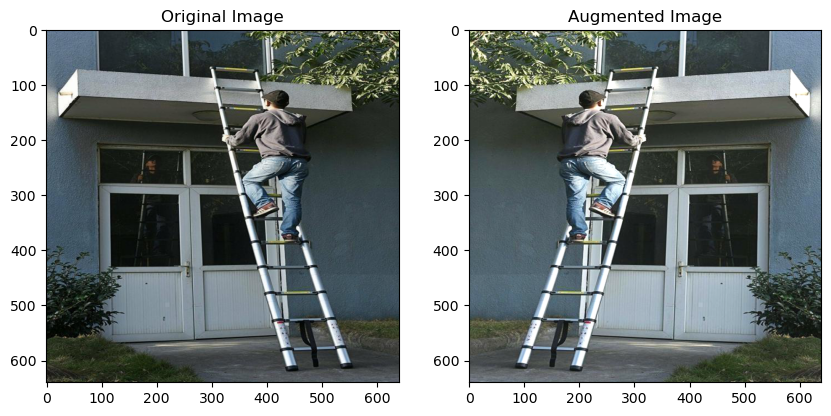

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from albumentations import Compose, HorizontalFlip, RandomBrightnessContrast, Rotate
import cv2

# Example data augmentation pipeline
augmentations = Compose([
    HorizontalFlip(p=0.5),
    RandomBrightnessContrast(p=0.5),
    Rotate(limit=15, p=0.5)
])

def augment_image(image):
    augmented = augmentations(image=image)
    return augmented['image']

# Load and augment a sample image
sample_image_path = '../logistics/-_10_jpg.rf.7216b8fd23d002354ad6cdd0d7691cd5.jpg'
sample_image = cv2.imread(sample_image_path)
augmented_image = augment_image(sample_image)

# Display original and augmented images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title('Augmented Image')
plt.imshow(cv2.cvtColor(augmented_image, cv2.COLOR_BGR2RGB))
plt.show()

Data augmentation significantly enhances the performance and robustness of the object detection system by introducing variability in the training dataset, which helps the model generalize better to unseen data. By applying transformations such as horizontal flipping, random brightness and contrast adjustments, rotation, scaling, translation, and adding Gaussian noise, the model is exposed to a broader range of scenarios and conditions, and can help augment underrepresented classes in the dataset.

### Anchor Box Configuration

/Users/nainireddy/opt/anaconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


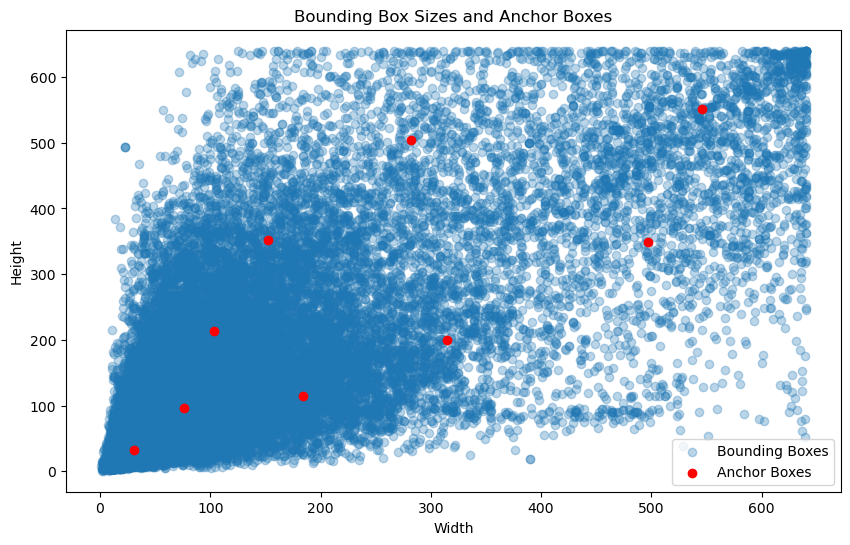

Optimal Anchor Boxes:
 [[545.67184335 551.3126266 ]
 [ 30.49207351  32.2921366 ]
 [314.63007284 199.26326743]
 [103.10790123 213.10567901]
 [152.74774421 351.27422519]
 [183.99347888 114.16926566]
 [282.48020158 504.78113751]
 [497.21619366 349.4490818 ]
 [ 75.81882412  95.70085794]]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load annotation data
annotations = pd.read_csv('annotations.csv')

# Extract width and height of bounding boxes
image_width, image_height = 640, 640
bbox_widths = annotations['width'] * image_width
bbox_heights = annotations['height'] * image_height
bbox_sizes = np.array(list(zip(bbox_widths, bbox_heights)))

# Perform k-means clustering to find optimal anchor box sizes
kmeans = KMeans(n_clusters=9, random_state=0).fit(bbox_sizes)
anchor_boxes = kmeans.cluster_centers_

# Plot the bounding box sizes and anchor boxes
plt.figure(figsize=(10, 6))
plt.scatter(bbox_widths, bbox_heights, alpha=0.3, label='Bounding Boxes')
plt.scatter(anchor_boxes[:, 0], anchor_boxes[:, 1], color='red', label='Anchor Boxes')
plt.title('Bounding Box Sizes and Anchor Boxes')
plt.xlabel('Width')
plt.ylabel('Height')
plt.legend()
plt.show()

print("Optimal Anchor Boxes:\n", anchor_boxes)

The k-means clustering algorithm identified nine optimal anchor boxes, reflecting the diverse range of object sizes in the dataset. These anchor boxes vary from large (e.g., 545.67 x 551.31) to small (e.g., 30.49 x 32.29), covering different aspect ratios and ensuring that the model can detect both large objects like trucks/cars, and small objects like helmets/gloves. The diversity in sizes and shapes of the anchor boxes will improve the model's detection accuracy across various object scales and orientations. Properly configured anchor boxes enhance the mean Average Precision (mAP) and overall detection performance, making the model more robust. Continuous evaluation and fine-tuning of these anchor boxes based on validation feedback are crucial to maintaining optimal detection accuracy.

## Analysis of System Parameters and Configurations: 5 Design Considerations (Module 7)

### Design Decision 1: Model Detection

**Significance:** The choice of YOLOv4-tiny for object detection is critical due to its balance between speed and accuracy. It allows real-time processing, which is essential for the system to operate efficiently in dynamic warehouse environments. YOLOv4-tiny's architecture ensures that the model can run on CPU-only resources, making it cost-effective and scalable.

**Plan:** To verify this design decision, we can compare YOLOv4-tiny's performance with other potential models such as SSD and Faster R-CNN. This comparison will include metrics like inference time, accuracy, precision, and recall on the provided test videos. We can use the Metrics class to calculate these metrics and visualize the results to identify the best performing 

**Implemented Design:** In the GitHub code, the YOLOv4-tiny model pre-trained and used for object detection.

### Design Decision 2: Frame Skipping Strategy

**Significance:** Implementing a frame skipping strategy (processing one frame every 30 frames) is crucial for managing computational load and ensuring real-time performance. This approach helps maintain a balance between processing speed and detection accuracy.

**Plan:** We can analyze the impact of different frame skipping intervals (e.g., 1, 10, 30) on system throughput and detection accuracy. This analysis will involve measuring the average frame processing time and detection latency for each interval. We can also assess the trade-offs between processing fewer frames and maintaining detection accuracy.

**Implemented Design:** In the GitHub code, the frame skipping interval of 30 was used (one frame per second).

### Design Decision 3: Non-Maximal Suppression (NMS) Configuration

**Significance:** The configuration of the NMS algorithm is vital for reducing false positives and ensuring that only the most accurate bounding boxes are retained. NMS helps improve the precision of object detection by filtering out overlapping detections. The score threshold is used to filter out low-confidence detections before applying NMS. It ensures that only detections with a confidence score above a certain level are considered for further processing. The IOU threshold is used during the NMS process to determine whether two bounding boxes are sufficiently overlapping. If the IoU of two bounding boxes exceeds this threshold, the box with the lower confidence score is suppressed (i.e., removed). This helps in retaining only the most relevant bounding box for each detected object, thereby reducing redundancy and improving precision.

**Plan:** We can experiment with different IoU thresholds, and different score thresolds for NMS and evaluate their impact on precision, recall, and F1 score. This analysis will help determine the optimal thresholds that balance false positives and true detections.

**Implemented Design:** In the GitHub code, a score thresold of 0.5 and IoU threshold of 0.4 was used. 

### Design Decision 4: Hard Negative Mining

**Significance:** Hard Negative Mining is essential for improving the model's robustness by identifying and augmenting difficult examples that the model struggles to classify correctly. This process enhances the model's ability to handle challenging scenarios and reduces false positives.

**Plan:** We can use the provided logistics dataset to identify the top-N hard negatives based on total loss. We will then apply various augmentations (e.g., flipping, rotation, brightness adjustment) to these images. The effectiveness of these augmentations will be assessed by comparing the loss values before and after augmentation.

**Implemented Design:** In the GitHub code, retraining was not implemented, but the retrieval of the top-N hard negatives based on the total loss has been implemented. The system defaults to the top 10 hard negatives. 

### Design Decision 5: Annotation Formats for Storing Detections

**Significance:** The choice of annotation format (PASCAL, YOLO, or COCO) for storing detections affects the ease of integration with other tools and workflows. Each format has its advantages, and selecting the appropriate one is crucial for interoperability and further processing.

**Plan:** We can store detections in all three formats for a subset of the test videos and compare the file sizes, ease of parsing, and compatibility with common object detection frameworks. This analysis will help determine the most suitable format for the system's requirements.

**Implemented Design:** In the GitHub code, the system can accomodate all three annotation formats for storing detections, as specified by the user. However, the system is defaulted to the YOLO format if no input is given.